# ESM-2 3B siamese NN for operon pair classification

## Loading ESM-2 and generating embeddings

In [ ]:
import numpy as np
import pandas as pd

In [ ]:
!pip install -U transformers

In [5]:
!pip install tqdm accelerate torch

In [2]:
import numpy as np
import pandas as pd
import torch
from transformers import AutoTokenizer, EsmModel
from torch.utils.data import DataLoader, Dataset
from tqdm.notebook import tqdm
from pathlib import Path

MODEL_NAME  = "facebook/esm2_t36_3B_UR50D"
BATCH_SIZE  = 4       # lower if OOM; try 1-2 for 3B on a 16 GB GPU
MAX_LENGTH  = 1024    # ESM-2 hard limit
HALF_PREC   = True    # fp16 halves VRAM usage — fine for inference
SEQ1_COL    = "sequence_1"
SEQ2_COL    = "sequence_2"
LABEL_COL   = "label"
OUTPUT_PATH = Path("embeddings_dgeb.npz")

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {DEVICE}")

Device: cuda


In [ ]:
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
model     = EsmModel.from_pretrained(MODEL_NAME)

if HALF_PREC:
    model = model.half()

model = model.to(DEVICE).eval()
print(f"Hidden size: {model.config.hidden_size}")

### Fetching dataset from DGEB and concating

In [ ]:
cyano = pd.read_parquet("hf://datasets/tattabio/cyano_operonic_pair/data/train-00000-of-00001.parquet")
vibrio = pd.read_parquet("hf://datasets/tattabio/vibrio_operonic_pair/data/train-00000-of-00001.parquet")
ecoli = pd.read_parquet("hf://datasets/tattabio/ecoli_operonic_pair/data/train-00000-of-00001.parquet")
tatta_bio_df = pd.concat([cyano, vibrio, ecoli],ignore_index=True)

### COnverting Raw DGEB data into a Dataframe of pairs

In [ ]:
def create_pairs(df: pd.DataFrame) -> pd.DataFrame:
    # Extract genome accession and positional index from entry
    df = df.copy()
    df['genome'] = df['Entry'].str.extract(r'lcl\|(.*?)_prot')
    df['idx'] = df['Entry'].str.extract(r'_(\d+)$').astype(int)
    
    # Sort by genome and position
    df = df.sort_values(['genome', 'idx']).reset_index(drop=True)
    
    pairs = []
    for genome, group in df.groupby('genome'):
        group = group.reset_index(drop=True)
        for i in range(len(group) - 1):
            # Only pair if indices are consecutive
            if group.loc[i+1, 'idx'] == group.loc[i, 'idx'] + 1:
                pairs.append({
                    'sequence_1': group.loc[i, 'Sequence'],
                    'sequence_2': group.loc[i+1, 'Sequence'],
                    'label': group.loc[i, 'Label']
                })
    
    return pd.DataFrame(pairs)
tatta_pairs = create_pairs(tatta_bio_df)

In [ ]:
class SequenceDataset(Dataset):
    def __init__(self, seqs):  self.seqs = seqs
    def __len__(self):         return len(self.seqs)
    def __getitem__(self, i):  return self.seqs[i]


def mean_pool(hidden_states, attention_mask):
    """Average over real (non-padding) token positions."""
    mask   = attention_mask.unsqueeze(-1).float()   # [B, L, 1]
    summed = (hidden_states * mask).sum(dim=1)       # [B, d]
    counts = mask.sum(dim=1).clamp(min=1e-9)         # [B, 1]
    return summed / counts                            # [B, d]


@torch.no_grad()
def embed(sequences, desc="Embedding"):
    loader = DataLoader(SequenceDataset(sequences),
                        batch_size=BATCH_SIZE, shuffle=False)
    parts = []
    for batch in tqdm(loader, desc=desc):
        inputs = tokenizer(
            list(batch),
            return_tensors="pt",
            padding=True,
            truncation=True,
            max_length=MAX_LENGTH,
        ).to(DEVICE)
        out = model(**inputs)
        emb = mean_pool(out.last_hidden_state, inputs["attention_mask"])
        parts.append(emb.float().cpu().numpy())
    return np.vstack(parts)

In [ ]:
emb_a = embed(tatta_pairs[SEQ1_COL].tolist(), desc="Gene A")
emb_b = embed(tatta_pairs[SEQ2_COL].tolist(), desc="Gene B")

print(f"emb_a: {emb_a.shape}")   # (N, d_model)
print(f"emb_b: {emb_b.shape}")

In [ ]:
X = np.concatenate(
    [emb_a, emb_b, emb_a - emb_b, emb_a * emb_b],
    axis=1,
)
y = tatta_pairs[LABEL_COL].to_numpy()

print(f"Fused X : {X.shape}")         # (N, 4 × d_model)
print(f"Labels  : {y.shape}")
print(f"Positive pairs: {y.sum()} / {len(y)}  ({100*y.mean():.1f}%)")

In [ ]:
# Saves fused features, labels, and raw embeddings separately
# so you can try different fusion strategies without re-running
np.savez_compressed(
    OUTPUT_PATH,
    X=X, y=y,
    emb_a=emb_a, emb_b=emb_b,
)
print(f"Saved → {OUTPUT_PATH}  ({OUTPUT_PATH.stat().st_size / 1e6:.1f} MB)")

In [ ]:
data = np.load(OUTPUT_PATH)
print({k: data[k].shape for k in data.files})

# Quick sanity check
from sklearn.dummy import DummyClassifier
from sklearn.model_selection import cross_val_score

dummy = DummyClassifier(strategy="most_frequent")
scores = cross_val_score(dummy, data["X"], data["y"], cv=5, scoring="roc_auc")
print(f"Dummy AUROC baseline: {scores.mean():.3f} ± {scores.std():.3f}")

## Training an MLP on the embeddings to classify

In [1]:
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from pathlib import Path
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score

In [2]:
TRAIN_PATH  = Path("/kaggle/input/datasets/kennethrodrigues/operon-esm-2-3b-embeddings/embeddings.npz")
VAL_PATH    = Path("/kaggle/input/datasets/kennethrodrigues/operon-esm-2-3b-embeddings/val_embeddings.npz")
MODEL_PATH  = Path("mlp_operon.pt")
PLOT_PATH   = Path("loss_curve_2.png")

BATCH_SIZE  = 256
EPOCHS      = 100
LR          = 1e-4
DROPOUT     = 0.3
HIDDEN_DIMS = [4096, 1024, 256, 64]
DEVICE      = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {DEVICE}")

Device: cuda


In [7]:
EPOCHS      = 200          # AUROC hasn't plateaued yet
DROPOUT     = 0.5          # was 0.4 — train loss too close to zero
LR          = 1e-4         # was 3e-4 — slow down

# in AdamW
weight_decay = 0.1         # was 1e-2 — needs more regularisation
PLOT_PATH   = Path("loss_curve_3.png")


In [8]:
def load_split(path):
    data = np.load(path)
    X = torch.tensor(data["X"], dtype=torch.float32)
    y = torch.tensor(data["y"], dtype=torch.float32)
    print(f"{path.name}  →  X: {X.shape}  y: {y.shape}  "
          f"pos rate: {y.mean():.3f}")
    return X, y

X_train, y_train = load_split(TRAIN_PATH)
X_val,   y_val   = load_split(VAL_PATH)

input_dim = X_train.shape[1]
print(f"\nInput dim: {input_dim}")

embeddings.npz  →  X: torch.Size([37126, 10240])  y: torch.Size([37126])  pos rate: 0.501
val_embeddings.npz  →  X: torch.Size([15912, 10240])  y: torch.Size([15912])  pos rate: 0.499

Input dim: 10240


In [9]:
# compute positive weight to handle class imbalance
pos_weight = ((y_train == 0).sum() / (y_train == 1).sum())
print(f"pos_weight for BCEWithLogitsLoss: {pos_weight:.2f}")

train_ds = TensorDataset(X_train, y_train)
val_ds   = TensorDataset(X_val,   y_val)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False)

pos_weight for BCEWithLogitsLoss: 1.00


In [10]:
class OperonMLP(nn.Module):
    def __init__(self, input_dim, hidden_dims, dropout):
        super().__init__()
        layers = []
        prev = input_dim
        for h in hidden_dims:
            layers += [
                nn.Linear(prev, h),
                nn.BatchNorm1d(h),
                nn.ReLU(),
                nn.Dropout(dropout),
            ]
            prev = h
        layers.append(nn.Linear(prev, 1))   # raw logit; no sigmoid here
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x).squeeze(-1)


model     = OperonMLP(input_dim, HIDDEN_DIMS, DROPOUT).to(DEVICE)
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight.to(DEVICE))
optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=0.1)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)

total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(model)
print(f"\nTrainable parameters: {total_params:,}")

OperonMLP(
  (net): Sequential(
    (0): Linear(in_features=10240, out_features=4096, bias=True)
    (1): BatchNorm1d(4096, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.5, inplace=False)
    (4): Linear(in_features=4096, out_features=1024, bias=True)
    (5): BatchNorm1d(1024, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.5, inplace=False)
    (8): Linear(in_features=1024, out_features=256, bias=True)
    (9): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): Dropout(p=0.5, inplace=False)
    (12): Linear(in_features=256, out_features=64, bias=True)
    (13): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (14): ReLU()
    (15): Dropout(p=0.5, inplace=False)
    (16): Linear(in_features=64, out_features=1, bias=True)
  )
)

Trainable parameters: 46,432,257


In [ ]:
def smooth_labels(y, smoothing=0.1):
    return y * (1 - smoothing) + 0.5 * smoothing


history       = {"train_loss": [], "val_loss": [], "val_auroc": []}
best_auroc    = 0.0
best_epoch    = 0
epochs_no_imp = 0
patience      = 20

for epoch in range(1, EPOCHS + 1):

    # ── train ──────────────────────────────────────────────────────────────
    model.train()
    train_loss = 0.0
    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(DEVICE), y_batch.to(DEVICE)
        optimizer.zero_grad()
        loss = criterion(model(X_batch), smooth_labels(y_batch))
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        train_loss += loss.item() * len(X_batch)
    train_loss /= len(train_ds)

    # ── validate ───────────────────────────────────────────────────────────
    model.eval()
    val_loss  = 0.0
    val_probs = []
    val_true  = []
    with torch.no_grad():
        for X_batch, y_batch in val_loader:
            X_batch, y_batch = X_batch.to(DEVICE), y_batch.to(DEVICE)
            logits = model(X_batch)
            val_loss += criterion(logits, y_batch).item() * len(X_batch)
            val_probs.append(torch.sigmoid(logits).cpu().numpy())
            val_true.append(y_batch.cpu().numpy())
    val_loss  /= len(val_ds)
    val_auroc  = roc_auc_score(
                     np.concatenate(val_true),
                     np.concatenate(val_probs))

    scheduler.step()

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["val_auroc"].append(val_auroc)

    # ── early stopping on AUROC ────────────────────────────────────────────
    if val_auroc > best_auroc:
        best_auroc    = val_auroc
        best_epoch    = epoch
        epochs_no_imp = 0
        torch.save({
            "model_state_dict": model.state_dict(),
            "input_dim":        input_dim,
            "hidden_dims":      HIDDEN_DIMS,
            "dropout":          DROPOUT,
            "epoch":            epoch,
            "val_auroc":        val_auroc,
        }, MODEL_PATH)
    else:
        epochs_no_imp += 1

    if epoch % 5 == 0 or epoch == 1:
        print(f"Epoch {epoch:>3}/{EPOCHS}  "
              f"train_loss: {train_loss:.4f}  "
              f"val_loss: {val_loss:.4f}  "
              f"val_AUROC: {val_auroc:.4f}  "
              f"best: {best_auroc:.4f} @ {best_epoch}  "
              f"patience: {epochs_no_imp}/{patience}")

    if epochs_no_imp >= patience:
        print(f"\nEarly stopping — no AUROC improvement for {patience} epochs.")
        break

print(f"\nBest val AUROC: {best_auroc:.4f} at epoch {best_epoch}")

In [ ]:
torch.save({
    "model_state_dict": model.state_dict(),
    "input_dim":        input_dim,
    "hidden_dims":      HIDDEN_DIMS,
    "dropout":          DROPOUT,
    "history":          history,
}, MODEL_PATH)

print(f"Model saved → {MODEL_PATH}")

In [ ]:
n_epochs = len(history["train_loss"])   # actual epochs run, not EPOCHS
epochs   = range(1, n_epochs + 1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle("Operon MLP — Training", fontsize=13, fontweight="bold")

# loss
ax1.plot(epochs, history["train_loss"], label="Train loss", linewidth=1.8)
ax1.plot(epochs, history["val_loss"],   label="Val loss",   linewidth=1.8, linestyle="--")
ax1.set_xlabel("Epoch")
ax1.set_ylabel("BCE Loss")
ax1.set_title("Loss")
ax1.legend()
ax1.grid(alpha=0.3)

# AUROC
best_epoch = int(np.argmax(history["val_auroc"])) + 1
best_auroc = max(history["val_auroc"])

ax2.plot(epochs, history["val_auroc"], color="tab:green", linewidth=1.8)
ax2.set_xlabel("Epoch")
ax2.set_ylabel("AUROC")
ax2.set_title("Validation AUROC")
ax2.set_ylim(0.5, 1.0)
ax2.axhline(0.5, color="grey", linestyle=":", linewidth=1, label="Random baseline")
ax2.axvline(best_epoch, color="tab:red", linestyle="--", alpha=0.6,
            label=f"Best: {best_auroc:.4f} @ epoch {best_epoch}")
ax2.legend()
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(PLOT_PATH, dpi=150, bbox_inches="tight")
plt.show()
print(f"Plot saved → {PLOT_PATH}")
print(f"Best val AUROC: {best_auroc:.4f} at epoch {best_epoch}")
print(f"Early stopping at epoch {n_epochs}/{EPOCHS}")

## Evaluating the model on the DGEB datast

In [3]:
test_data = np.load("/kaggle/input/datasets/kennethrodrigues/dgeb-embeddings-esm-3/embeddings_dgeb.npz")
X_test = torch.tensor(test_data["X"], dtype=torch.float32)
y_test = torch.tensor(test_data["y"], dtype=torch.float32)

print(f"X_test : {X_test.shape}")
print(f"y_test : {y_test.shape}")
print(f"Positive rate: {y_test.mean():.3f}")

X_test : torch.Size([5183, 10240])
y_test : torch.Size([5183])
Positive rate: 0.314


In [13]:
ckpt = torch.load(MODEL_PATH, map_location=DEVICE, weights_only=False)

loaded_model = OperonMLP(
    ckpt["input_dim"],
    ckpt["hidden_dims"],
    ckpt["dropout"],
).to(DEVICE)

loaded_model.load_state_dict(ckpt["model_state_dict"])
loaded_model.eval()

OperonMLP(
  (net): Sequential(
    (0): Linear(in_features=10240, out_features=4096, bias=True)
    (1): BatchNorm1d(4096, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.5, inplace=False)
    (4): Linear(in_features=4096, out_features=1024, bias=True)
    (5): BatchNorm1d(1024, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.5, inplace=False)
    (8): Linear(in_features=1024, out_features=256, bias=True)
    (9): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): Dropout(p=0.5, inplace=False)
    (12): Linear(in_features=256, out_features=64, bias=True)
    (13): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (14): ReLU()
    (15): Dropout(p=0.5, inplace=False)
    (16): Linear(in_features=64, out_features=1, bias=True)
  )
)

In [14]:
from sklearn.metrics import (
    roc_auc_score, average_precision_score,
    classification_report, confusion_matrix,
    roc_curve, precision_recall_curve, ConfusionMatrixDisplay,
)

test_ds     = TensorDataset(X_test, y_test)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False)

all_probs = []
all_true  = []

with torch.no_grad():
    for X_batch, y_batch in test_loader:
        X_batch = X_batch.to(DEVICE)
        logits  = loaded_model(X_batch)
        probs   = torch.sigmoid(logits).cpu().numpy()
        all_probs.append(probs)
        all_true.append(y_batch.numpy())

probs = np.concatenate(all_probs)
true  = np.concatenate(all_true).astype(int)

In [15]:
# Default 0.5 threshold is often wrong with imbalanced data.
# Youden's J picks the threshold that maximises sensitivity + specificity.
fpr, tpr, roc_thresholds = roc_curve(true, probs)
youden_idx  = np.argmax(tpr - fpr)
best_thresh = roc_thresholds[youden_idx]

preds = (probs >= best_thresh).astype(int)

print(f"Optimal threshold (Youden's J): {best_thresh:.4f}")
print(f"  — using 0.5 would give {(probs >= 0.5).mean():.3f} predicted positive rate")
print(f"  — optimal gives         {preds.mean():.3f} predicted positive rate")

Optimal threshold (Youden's J): 0.1140
  — using 0.5 would give 0.373 predicted positive rate
  — optimal gives         0.484 predicted positive rate


In [16]:
from sklearn.metrics import (
    matthews_corrcoef, balanced_accuracy_score, f1_score,
    precision_score, recall_score, accuracy_score,
)

auroc  = roc_auc_score(true, probs)
auprc  = average_precision_score(true, probs)
mcc    = matthews_corrcoef(true, preds)
bal_acc= balanced_accuracy_score(true, preds)
acc    = accuracy_score(true, preds)
f1     = f1_score(true, preds)
prec   = precision_score(true, preds)
rec    = recall_score(true, preds)

print("=" * 45)
print("  Test set evaluation")
print("=" * 45)
print(f"  Threshold used  : {best_thresh:.4f}  (Youden's J)")
print("-" * 45)
print(f"  AUROC           : {auroc:.4f}")
print(f"  AUPRC           : {auprc:.4f}")
print(f"  MCC             : {mcc:.4f}")
print(f"  Balanced acc    : {bal_acc:.4f}")
print(f"  Accuracy        : {acc:.4f}")
print(f"  F1              : {f1:.4f}")
print(f"  Precision       : {prec:.4f}")
print(f"  Recall          : {rec:.4f}")
print("=" * 45)
print()
print(classification_report(true, preds,
                             target_names=["Non-operonic", "Operonic"]))

  Test set evaluation
  Threshold used  : 0.1140  (Youden's J)
---------------------------------------------
  AUROC           : 0.7104
  AUPRC           : 0.5172
  MCC             : 0.2918
  Balanced acc    : 0.6571
  Accuracy        : 0.6411
  F1              : 0.5505
  Precision       : 0.4536
  Recall          : 0.7001

              precision    recall  f1-score   support

Non-operonic       0.82      0.61      0.70      3556
    Operonic       0.45      0.70      0.55      1627

    accuracy                           0.64      5183
   macro avg       0.64      0.66      0.63      5183
weighted avg       0.70      0.64      0.65      5183



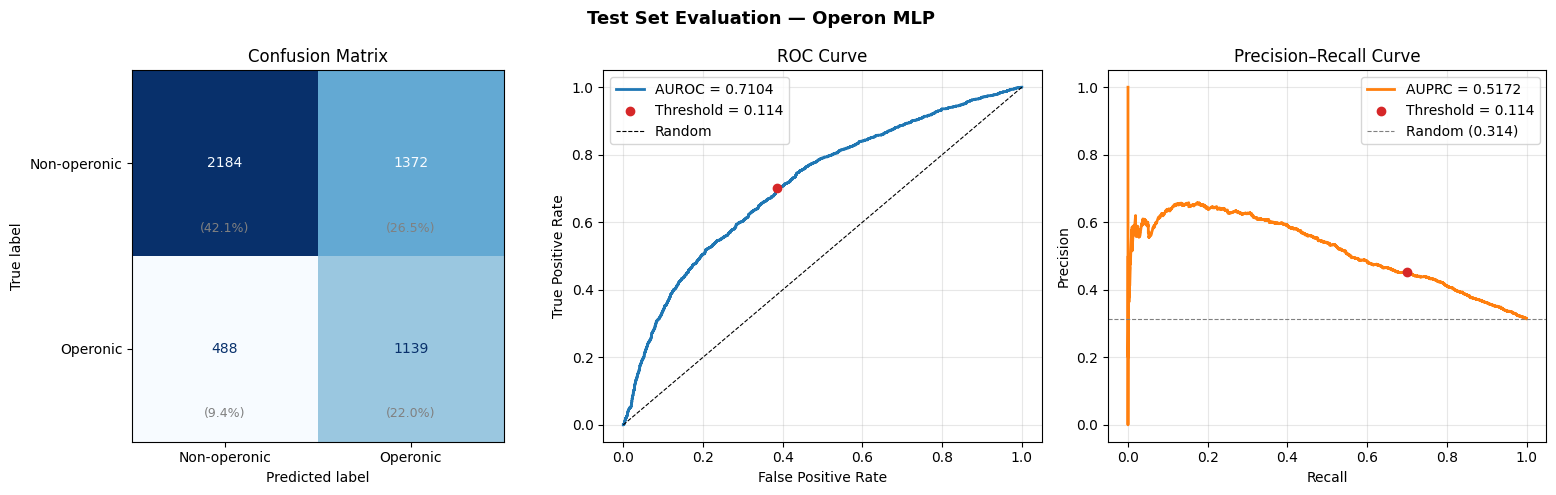

Saved → test_evaluation.png


In [17]:
EVAL_PLOT_PATH = Path("test_evaluation.png")

cm = confusion_matrix(true, preds)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("Test Set Evaluation — Operon MLP", fontsize=13, fontweight="bold")

# ── Confusion matrix ───────────────────────────────────────────────────────
disp = ConfusionMatrixDisplay(cm, display_labels=["Non-operonic", "Operonic"])
disp.plot(ax=axes[0], colorbar=False, cmap="Blues")
axes[0].set_title("Confusion Matrix")

# add % annotations
total = cm.sum()
for (r, c), val in np.ndenumerate(cm):
    axes[0].text(c, r + 0.35, f"({100*val/total:.1f}%)",
                 ha="center", va="center", fontsize=9, color="grey")

# ── ROC curve ──────────────────────────────────────────────────────────────
axes[1].plot(fpr, tpr, color="tab:blue", linewidth=2,
             label=f"AUROC = {auroc:.4f}")
axes[1].scatter(fpr[youden_idx], tpr[youden_idx], color="tab:red", zorder=5,
                label=f"Threshold = {best_thresh:.3f}")
axes[1].plot([0, 1], [0, 1], "k--", linewidth=0.8, label="Random")
axes[1].set_xlabel("False Positive Rate")
axes[1].set_ylabel("True Positive Rate")
axes[1].set_title("ROC Curve")
axes[1].legend()
axes[1].grid(alpha=0.3)

# ── Precision-Recall curve ─────────────────────────────────────────────────
pr_prec, pr_rec, pr_thresh = precision_recall_curve(true, probs)
closest_idx = np.argmin(np.abs(pr_thresh - best_thresh))

axes[2].plot(pr_rec, pr_prec, color="tab:orange", linewidth=2,
             label=f"AUPRC = {auprc:.4f}")
axes[2].scatter(pr_rec[closest_idx], pr_prec[closest_idx],
                color="tab:red", zorder=5,
                label=f"Threshold = {best_thresh:.3f}")
axes[2].axhline(true.mean(), color="grey", linestyle="--",
                linewidth=0.8, label=f"Random ({true.mean():.3f})")
axes[2].set_xlabel("Recall")
axes[2].set_ylabel("Precision")
axes[2].set_title("Precision–Recall Curve")
axes[2].legend()
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(EVAL_PLOT_PATH, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved → {EVAL_PLOT_PATH}")